In [1]:
import numpy as np
from numpy.linalg import norm
import math, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
#spatial funcs for WoS

def closestPoint(v, s):
    u = s[1] - s[0]
    rate = max(0, min(u.dot(v - s[0])/u.dot(u), 1))
    return (s[0] + rate*(s[1] - s[0]))

def shortestDistance(v, segments):
    r = float("inf")
    for s in segments:
        u = closestPoint(v, s)
        if norm(v - u) < r:
            r = norm(v - u)
    return r

In [3]:
def Green(r, R):
    return np.log(R/r)/(2 * math.pi)

In [4]:
def pathGenerator(v, segments, g, f, eps = 0.01, maxSteps = 16, maxR = 10):
    x0 = v
    s = 0
    for step in range(0, maxSteps): 
        r = min([shortestDistance(x0, segments), maxR])
        if r < eps: 
            return g(x0) + s
        theta = random.uniform(0, 2*math.pi)
        x0 = x0 + np.array([r * math.cos(theta), r * math.sin(theta)])
        
        source_r = math.sqrt(random.uniform(0, 1)) * r
        source_theta = random.uniform(0, 2*math.pi)
        source_local = x0 + np.array([source_r * math.cos(source_theta), source_r * math.sin(source_theta)])
        s -= (math.pi * r * r)*f(source_local)*Green(source_r, r)
    return 0

In [5]:
def solver(v, segments, g, f, nWalks = 100):
    vWalks = 0   
    sumEst = 0
    for i in range(0, nWalks):
        result = pathGenerator(v, segments, g, f)
        if result != 0:
            vWalks += 1
            sumEst += result
    if vWalks == 0:
        return 0
    return sumEst/vWalks

In [6]:
# set up the problem
segments = [np.array([[-1, -1], [-1, 1]]), np.array([[-1, -1], [1, -1]]), np.array([[1, -1], [1, 1]]), np.array([[-1, 1], [1, 1]])]
#v = np.array([0, 0])
def boundary(v):
    return v[0] * v[1] * v[1]

#source
def source(v): 
    return 2 * v[0]

In [7]:
#####evenly distributed start places
target = []
width = range(1, 100)
height = range(1, 100)
for i in width:
    for j in height:
        target.append(np.array([i/50 - 1, j/50 - 1]))

print(len(target))

###### pure random start places
#target = np.random.rand(10000, 2)
#target = 2* target - 1

#####QMC start places
#import scipy.stats as stats
#qmcGenerator = stats.qmc.Sobol(d=2)
#target = qmcGenerator.random(n=40000)
#target = 2* target - 1

9801


In [8]:
result = []
for v in target:
    result.append(solver(v, segments, boundary, source))

print(result[100])

-0.8932652056750893


In [9]:
target1 = np.array(target).reshape(-1, 2).astype("float32")
result1 = np.array(result)

In [10]:
YNNmodel = keras.Sequential( # a list of fully connected layers
    [
        keras.Input(shape = (2)), #not necessary, but for model.summary
        keras.layers.Dense(128, activation = 'relu'),
        keras.layers.Dense(64, activation = 'relu'),
        keras.layers.Dense(32, activation = 'relu'),
        keras.layers.Dense(1), #no softmax activation
    ]
)
print(YNNmodel.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               384       
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 10,753
Trainable params: 10,753
Non-trainable params: 0
_________________________________________________________________
None


In [11]:
YNNmodel.compile( # netwrok configurations
    loss = keras.losses.MeanSquaredError(), # do the output softmax
    optimizer = keras.optimizers.Adam(lr = 1e-4),
    #metrics = ["accuracy"],
)

YNNmodel.fit(target1, result1, batch_size = 256, epochs = 50, verbose = 2) # concrete training of the network

Epoch 1/50
39/39 - 0s - loss: 0.0245 - 147ms/epoch - 4ms/step
Epoch 2/50


2024-11-12 15:19:57.799484: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


39/39 - 0s - loss: 0.0069 - 19ms/epoch - 479us/step
Epoch 3/50
39/39 - 0s - loss: 0.0030 - 20ms/epoch - 500us/step
Epoch 4/50
39/39 - 0s - loss: 0.0017 - 21ms/epoch - 526us/step
Epoch 5/50
39/39 - 0s - loss: 0.0013 - 20ms/epoch - 513us/step
Epoch 6/50
39/39 - 0s - loss: 0.0012 - 20ms/epoch - 517us/step
Epoch 7/50
39/39 - 0s - loss: 0.0011 - 20ms/epoch - 510us/step
Epoch 8/50
39/39 - 0s - loss: 0.0010 - 21ms/epoch - 527us/step
Epoch 9/50
39/39 - 0s - loss: 9.9346e-04 - 20ms/epoch - 517us/step
Epoch 10/50
39/39 - 0s - loss: 9.9533e-04 - 20ms/epoch - 512us/step
Epoch 11/50
39/39 - 0s - loss: 9.8243e-04 - 20ms/epoch - 523us/step
Epoch 12/50
39/39 - 0s - loss: 9.5892e-04 - 20ms/epoch - 513us/step
Epoch 13/50
39/39 - 0s - loss: 9.5973e-04 - 20ms/epoch - 519us/step
Epoch 14/50
39/39 - 0s - loss: 9.4765e-04 - 20ms/epoch - 520us/step
Epoch 15/50
39/39 - 0s - loss: 9.6415e-04 - 20ms/epoch - 511us/step
Epoch 16/50
39/39 - 0s - loss: 9.5355e-04 - 20ms/epoch - 512us/step
Epoch 17/50
39/39 - 0s - lo

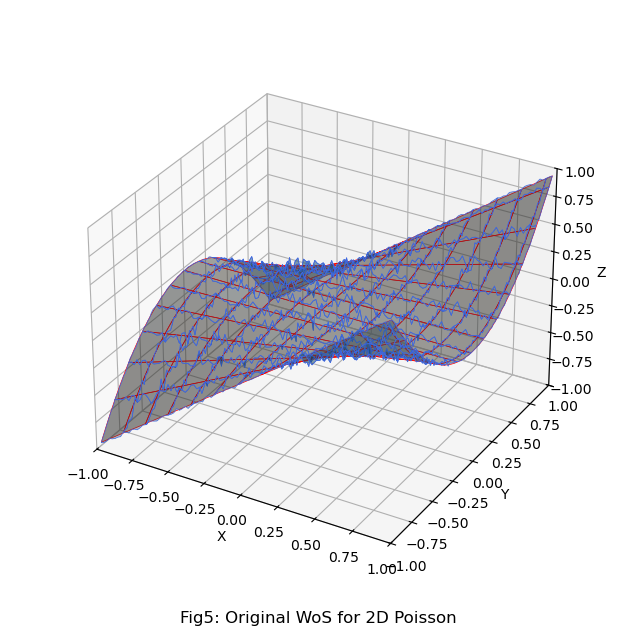

In [12]:
target1 = np.array(target).reshape(-1, 2).astype("float32")
X = target1[:, 0]
Y = target1[:, 1]

X = np.array(X).reshape(99, 99)
Y = np.array(Y).reshape(99, 99)
Z = np.array(result).reshape(99, 99)
Z1 = X*Y*Y

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
#ax.plot_surface(X, Y, Z2, edgecolor='green', lw=0.5, rstride=8, cstride=8,
#                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='Z')

ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Fig5: Original WoS for 2D Poisson", y=-0.01)
#plt.show()
plt.savefig('WoSorigin2Dpoisson.png', bbox_inches='tight')

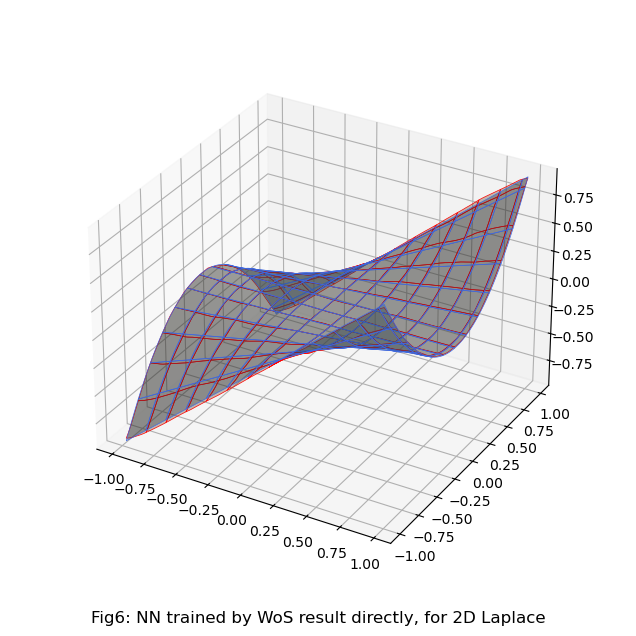

In [13]:
target = []
width = range(1, 100)
height = range(1, 100)
for i in width:
    for j in height:
        target.append(np.array([i/50 - 1, j/50 - 1]))
target1 = np.array(target).reshape(-1, 2).astype("float32")
X = target1[:, 0]
Y = target1[:, 1]
Z = []
for i in target1:
        Z.append(YNNmodel(np.array(i).reshape([1, 2]).astype("float32")))

X = np.array(X).reshape(99, 99)
Y = np.array(Y).reshape(99, 99)
Z = np.array(Z).reshape(99, 99)

Z1 = X*Y*Y

ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
#ax.plot_surface(X, Y, Z2, edgecolor='green', lw=0.5, rstride=8, cstride=8,
#                alpha=0.3)
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Fig6: NN trained by WoS result directly, for 2D Laplace", y=-0.01)
#plt.show()
plt.savefig('WoSsmoothed2Dpoisson.png', bbox_inches='tight')